# Drowsiness Detection — Improved Pipeline

# Blink & Eye Fatigue Detection Model

MobileNetV2 transfer-learning based drowsiness detection using eye images.

**Two-phase training:**
- **Phase 1**  Frozen MobileNetV2 base; train new classification head only (fast convergence).
- **Phase 2**  Unfreeze top 30 layers of base for fine-tuning (higher accuracy).

**Classes:** `drowsy` | `notdrowsy`

## 1. Imports & Configuration

In [1]:
# Core
import os, warnings, random
import numpy as np
import cv2
from pathlib import Path

In [2]:
#  TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
)

In [3]:
#  Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

In [4]:
#  Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches
import seaborn as sns

In [5]:
#  Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings('ignore')
print(f'TensorFlow {tf.__version__} | GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
# CONFIGURATION  — change only this cell


TRAIN_DATA_PATH = '/content/drive/MyDrive/FYP/train_data'
TEST_DATA_PATH  = '/content/drive/MyDrive/FYP/test_data'
MODEL_SAVE_PATH = '/content/models/best_blink_fatigue.keras'
LOG_DIR         = '/content/logs'

# Image
IMG_HEIGHT, IMG_WIDTH = 224, 224
CLASS_NAMES = ['drowsy', 'notdrowsy']   # alphabetical = class index order

# Training
BATCH_SIZE        = 32
VALIDATION_SPLIT  = 0.20
PHASE1_EPOCHS     = 20   # head-only training
PHASE2_EPOCHS     = 30   # fine-tuning top layers
UNFREEZE_LAYERS   = 30   # top N layers to unfreeze in Phase 2

PHASE1_LR = 1e-4   # was 1e-3  → reduced 10×
PHASE2_LR = 1e-5   # fine-tuning must be tiny

# Inference
DROWSY_THRESHOLD = 0.60

os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
print('Configuration loaded ✓')

Configuration loaded ✓


## 2. Mount Drive & Copy Data Locally

In [7]:
# Run only in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')

    import shutil
    GDRIVE_TRAIN = '/content/drive/MyDrive/FYP/train_data'
    GDRIVE_TEST  = '/content/drive/MyDrive/FYP/test_data'

    for src, dst in [(GDRIVE_TRAIN, TRAIN_DATA_PATH), (GDRIVE_TEST, TEST_DATA_PATH)]:
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)
        print(f'Copied {src} → {dst}')
except ImportError:
    print('Not in Colab — using paths as-is')

Mounted at /content/drive
Copied /content/drive/MyDrive/FYP/train_data → /content/data/train_data
Copied /content/drive/MyDrive/FYP/test_data → /content/data/test_data


## 3. Dataset Exploration

In [8]:
def count_dataset(root):
    """Count images per class in a directory-of-classes structure."""
    counts = {}
    for cls in sorted(os.listdir(root)):
        cls_path = os.path.join(root, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
            ])
    return counts

train_counts = count_dataset(TRAIN_DATA_PATH)
test_counts  = count_dataset(TEST_DATA_PATH)

print('=== TRAIN ===')
for k, v in train_counts.items(): print(f'  {k}: {v}')
print(f'  TOTAL: {sum(train_counts.values())}')

print('\n=== TEST ===')
for k, v in test_counts.items(): print(f'  {k}: {v}')
print(f'  TOTAL: {sum(test_counts.values())}')

=== TRAIN ===
  drowsy: 1606
  notdrowsy: 1776
  TOTAL: 3382

=== TEST ===
  drowsy: 394
  notdrowsy: 224
  TOTAL: 618


## 4. Data Pipeline

### Separate generators for train and validation

Using a **single** `ImageDataGenerator` with `validation_split` applies augmentation to
**both** subsets, which inflates val accuracy. Two separate generators is the correct pattern:
- `train_datagen` — augmentation ON
- `val_datagen`   — only `rescale` (or nothing, since preprocess_input is in the model)

In [17]:
def make_generators(train_path, val_path=None,
                    validation_split=VALIDATION_SPLIT,
                    batch_size=BATCH_SIZE):
    """
    Returns (train_gen, val_gen).

    If val_path is None, the validation split is carved from train_path using
    TWO separate ImageDataGenerator instances so that augmentation is NOT
    applied to the validation set — a common but critical bug.
    """
    # TRAIN generator — heavy augmentation
    train_datagen = ImageDataGenerator(
        validation_split   = validation_split if val_path is None else 0.0,
        # Geometric
        rotation_range     = 20,
        width_shift_range  = 0.15,
        height_shift_range = 0.15,
        horizontal_flip    = True,
        zoom_range         = 0.15,
        shear_range        = 0.10,
        # Photometric
        brightness_range   = [0.70, 1.30],
        channel_shift_range= 20.0,
        fill_mode          = 'nearest',
        # No rescale here — preprocess_input is baked into the model graph
    )

    train_gen = train_datagen.flow_from_directory(
        train_path,
        target_size = (IMG_HEIGHT, IMG_WIDTH),
        batch_size  = batch_size,
        class_mode  = 'categorical',
        subset      = 'training' if val_path is None else None,
        shuffle     = True,
        seed        = SEED,
    )

    #  VAL generator — NO augmentation
    val_datagen = ImageDataGenerator(
        validation_split = validation_split if val_path is None else 0.0,
        # No augmentation at all
    )

    val_source = val_path if val_path else train_path
    val_gen = val_datagen.flow_from_directory(
        val_source,
        target_size = (IMG_HEIGHT, IMG_WIDTH),
        batch_size  = batch_size,
        class_mode  = 'categorical',
        subset      = 'validation' if val_path is None else None,
        shuffle     = False,
        seed        = SEED,
    )

    return train_gen, val_gen


def compute_class_weights(data_path):
    from sklearn.utils.class_weight import compute_class_weight
    classes = sorted([
        d for d in os.listdir(data_path)
        if os.path.isdir(os.path.join(data_path, d))
    ])
    all_labels = []
    for idx, cls in enumerate(classes):
        n = len(os.listdir(os.path.join(data_path, cls)))
        all_labels.extend([idx] * n)
    all_labels = np.array(all_labels)
    cw = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
    cw_dict = {i: w for i, w in enumerate(cw)}
    print(f'Class weights: {cw_dict}')
    return cw_dict


train_gen, val_gen = make_generators(TRAIN_DATA_PATH)
class_weights = compute_class_weights(TRAIN_DATA_PATH)

Found 2706 images belonging to 2 classes.
Found 676 images belonging to 2 classes.
Class weights: {0: np.float64(1.0529265255292652), 1: np.float64(0.9521396396396397)}


In [18]:
assert os.path.exists(TRAIN_DATA_PATH), \
    f"Data not found at {TRAIN_DATA_PATH} — run the Drive mount cell first"

## 5. Model Architecture

### Changes vs original
| | Original | Improved |
|---|---|---|
| Head | Dense(256)→Drop→BN→Dense(128)→Drop→Dense(2) | Dense(128)→Drop(0.5)→Dense(2) |
| Regularisation | None | L2(1e-4) on Dense |
| Phase 1 LR | 1e-3 | 1e-4 |
| Phase 2 LR | 1e-5 | 1e-5 |
| Metrics | accuracy only | acc + AUC + Precision + Recall |
| LR schedule | ReduceLROnPlateau | CosineDecayRestarts |

In [24]:
def build_model(img_h=IMG_HEIGHT, img_w=IMG_WIDTH, l2=1e-4):
    """
    Builds a MobileNetV2-based binary classifier.
    preprocess_input is baked into the graph so raw [0,255] pixels are fine.
    """
    base = MobileNetV2(
        input_shape  = (img_h, img_w, 3),
        include_top  = False,
        weights      = 'imagenet',
    )
    base.trainable = False   # frozen for Phase 1

    inputs = keras.Input(shape=(img_h, img_w, 3), name='image_input')

    # ImageNet normalisation built into graph
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base(x, training=False)               # training=False keeps BN frozen
    x = layers.GlobalAveragePooling2D()(x)

    # Slim head — prevents overfitting on small dataset
    x = layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(l2),
        name='head_dense'
    )(x)
    x = layers.BatchNormalization(name='head_bn')(x)
    x = layers.Dropout(0.50, name='head_dropout')(x)
    outputs = layers.Dense(2, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='drowsiness_detector')
    return model


def compile_phase1(model):
    """Phase 1: train head only with moderate LR."""
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=PHASE1_LR),
        loss      = 'categorical_crossentropy',
        metrics   = [
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ],
    )


def unfreeze_and_compile_phase2(model, n_layers=UNFREEZE_LAYERS):
    base = model.get_layer('mobilenetv2_1.00_224')
    base.trainable = True
    for layer in base.layers[:-n_layers]:
        layer.trainable = False

    trainable = sum(np.prod(v.shape) for v in model.trainable_variables)
    print(f'Phase 2 trainable params: {trainable:,}')

    # Use plain float LR — ReduceLROnPlateau can't modify a LearningRateSchedule
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=PHASE2_LR),
        loss      = 'categorical_crossentropy',
        metrics   = [
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ],
    )


model = build_model()
compile_phase1(model)
model.summary()

Model: "drowsiness_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)    │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,722 (9.24 MB)

 Trainable params: 164,482 (642.51 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [25]:
train_gen, val_gen = make_generators(TRAIN_DATA_PATH)
class_weights = compute_class_weights(TRAIN_DATA_PATH)
print(f"✓ train batches: {len(train_gen)}  |  val batches: {len(val_gen)}")

Found 2706 images belonging to 2 classes.
Found 676 images belonging to 2 classes.
Class weights: {0: np.float64(1.0529265255292652), 1: np.float64(0.9521396396396397)}
✓ train batches: 85  |  val batches: 22


## 6. Callbacks

In [21]:
def make_callbacks(phase: int):
    tag = f'phase{phase}'
    return [
        ModelCheckpoint(
            filepath          = MODEL_SAVE_PATH,
            monitor           = 'val_accuracy',
            save_best_only    = True,
            save_weights_only = False,
            verbose           = 1,
        ),
        EarlyStopping(
            monitor              = 'val_accuracy',
            patience             = 8,
            restore_best_weights = True,
            verbose              = 1,
        ),
        ReduceLROnPlateau(
            monitor   = 'val_loss',
            factor    = 0.5,
            patience  = 4,
            min_lr    = 1e-7,
            verbose   = 1,
        ),
        TensorBoard(
            log_dir           = os.path.join(LOG_DIR, tag),
            histogram_freq    = 1,
            write_graph       = False,
        ),
    ]

## 7. Training — Phase 1 (Head Only)

In [22]:
print('=' * 60)
print('PHASE 1 — Training head only (backbone frozen)')
print(f'LR: {PHASE1_LR}  |  Max epochs: {PHASE1_EPOCHS}')
print('=' * 60)

h1 = model.fit(
    train_gen,
    epochs          = PHASE1_EPOCHS,
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = make_callbacks(phase=1),
    verbose         = 1,
)

print(f'\nPhase 1 complete.')
print(f'  Best val_accuracy : {max(h1.history["val_accuracy"]):.4f}')
print(f'  Best val_auc      : {max(h1.history["val_auc"]):.4f}')

PHASE 1 — Training head only (backbone frozen)
LR: 0.0001  |  Max epochs: 20
Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.7539 - auc: 0.8102 - loss: 0.6606 - precision: 0.7539 - recall: 0.7539
Epoch 1: val_accuracy improved from None to 0.99556, saving model to /content/models/best_blink_fatigue.keras

Epoch 1: finished saving model to /content/models/best_blink_fatigue.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8902 - auc: 0.9557 - loss: 0.3055 - precision: 0.8902 - recall: 0.8902 - val_accuracy: 0.9956 - val_auc: 0.9998 - val_loss: 0.1285 - val_precision: 0.9956 - val_recall: 0.9956 - learning_rate: 1.0000e-04
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 853ms/step - accuracy: 0.9805 - auc: 0.9984 - loss: 0.0744 - precision: 0.9805 - recall: 0.9805
Epoch 2: val_accuracy did not improve from 0.99556
85/85 ━━━━━━━━━━━━━━━━━━━━ 110s 919ms/step - accuracy: 0.9863 - auc: 0.9988 - loss: 0.0665 - precision: 0.9863 - recall: 0.9863 - val_accuracy: 0.9882 - v

## 8. Training — Phase 2 (Fine-tuning)

In [26]:
print('=' * 60)
print(f'PHASE 2 — Fine-tuning top {UNFREEZE_LAYERS} backbone layers')
print(f'LR: {PHASE2_LR}  |  Max epochs: {PHASE2_EPOCHS}')
print('=' * 60)

unfreeze_and_compile_phase2(model)

h2 = model.fit(
    train_gen,
    epochs          = PHASE2_EPOCHS,
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = make_callbacks(phase=2),
    verbose         = 1,
)

print(f'\nPhase 2 complete.')
print(f'  Best val_accuracy : {max(h2.history["val_accuracy"]):.4f}')
print(f'  Best val_auc      : {max(h2.history["val_auc"]):.4f}')

PHASE 2 — Fine-tuning top 30 backbone layers
LR: 1e-05  |  Max epochs: 30
Phase 2 trainable params: 1,690,882
Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.6772 - auc: 0.7422 - loss: 0.7985 - precision: 0.6772 - recall: 0.6772
Epoch 1: val_accuracy improved from None to 0.56657, saving model to /content/models/best_blink_fatigue.keras

Epoch 1: finished saving model to /content/models/best_blink_fatigue.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 91s 858ms/step - accuracy: 0.7979 - auc: 0.8809 - loss: 0.5115 - precision: 0.7979 - recall: 0.7979 - val_accuracy: 0.5666 - val_auc: 0.7245 - val_loss: 0.6984 - val_precision: 0.5666 - val_recall: 0.5666 - learning_rate: 1.0000e-05
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.9300 - auc: 0.9803 - loss: 0.1973 - precision: 0.9300 - recall: 0.9300
Epoch 2: val_accuracy improved from 0.56657 to 0.72485, saving model to /content/models/best_blink_fatigue.keras

Epoch 2: finished saving model to /content/models/best_b

## 9. Training Visualisation Dashboard

Six plots covering every angle of model performance.

In [27]:
# Merge Phase 1 + Phase 2 histories
def merge_histories(h1, h2=None):
    merged = {k: list(v) for k, v in h1.history.items()}
    if h2:
        for k, v in h2.history.items():
            merged[k] = merged.get(k, []) + list(v)
    return merged

hist = merge_histories(h1, h2)
p1_end = len(h1.history['loss'])   # epoch index where Phase 2 starts
epochs = range(1, len(hist['loss']) + 1)

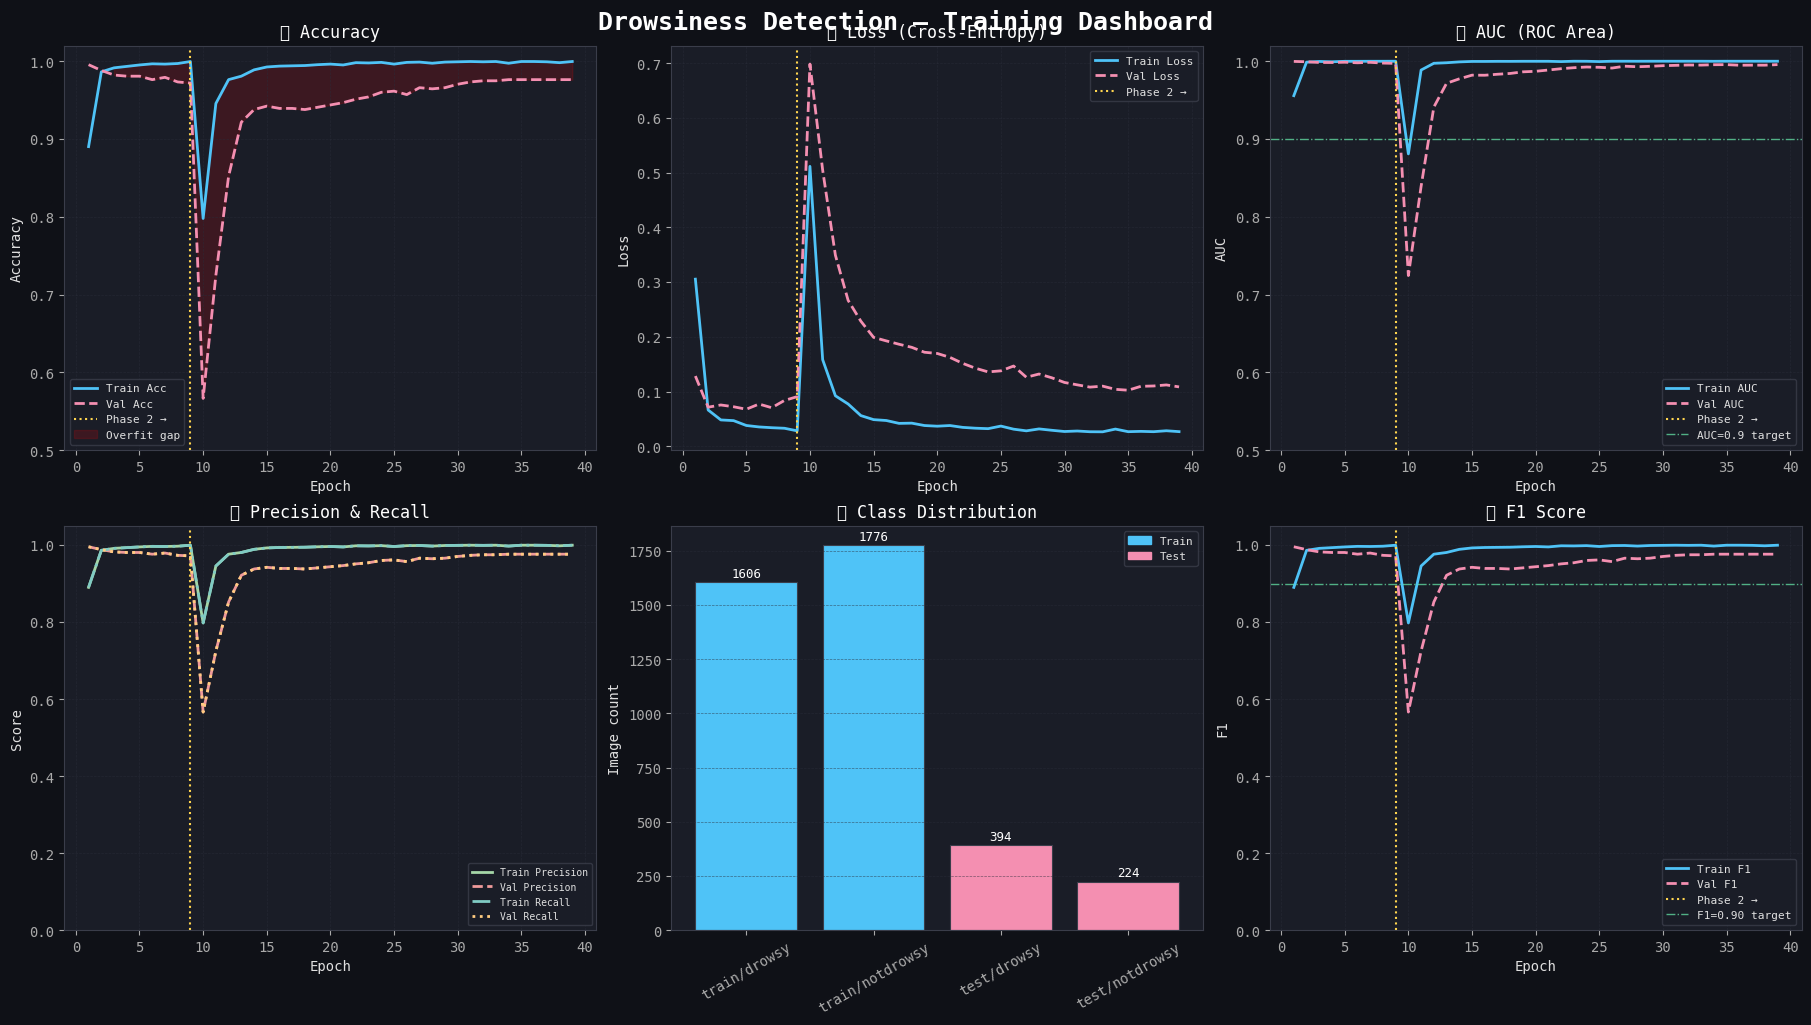

Dashboard saved to /content/training_dashboard.png


In [28]:
# Plot style
plt.rcParams.update({
    'figure.facecolor'  : '#0f1117',
    'axes.facecolor'    : '#1a1d27',
    'axes.edgecolor'    : '#3a3d4a',
    'axes.labelcolor'   : '#e0e0e0',
    'axes.titlecolor'   : '#ffffff',
    'xtick.color'       : '#aaaaaa',
    'ytick.color'       : '#aaaaaa',
    'grid.color'        : '#2a2d3a',
    'grid.alpha'        : 0.6,
    'legend.facecolor'  : '#1a1d27',
    'legend.edgecolor'  : '#3a3d4a',
    'legend.labelcolor' : '#e0e0e0',
    'font.family'       : 'monospace',
})

TRAIN_COLOR = '#4fc3f7'   # blue
VAL_COLOR   = '#f48fb1'   # pink
PHASE_COLOR = '#ffd54f'   # yellow dashed
GRID_KW     = dict(which='both', linestyle='--', linewidth=0.5)


fig = plt.figure(figsize=(18, 10), constrained_layout=True)
fig.suptitle(
    'Drowsiness Detection — Training Dashboard',
    fontsize=18, fontweight='bold', color='white', y=1.01
)

axes = fig.subplots(2, 3)


#  Plot 1: Accuracy
# WHY: Shows whether training and validation accuracy converge.
# If training >> validation → overfitting.
# The Phase 2 line shows whether fine-tuning hurt or helped generalisation.
ax = axes[0, 0]
ax.plot(epochs, hist['accuracy'],     color=TRAIN_COLOR, lw=2, label='Train Acc')
ax.plot(epochs, hist['val_accuracy'], color=VAL_COLOR,   lw=2, label='Val Acc', linestyle='--')
ax.axvline(p1_end, color=PHASE_COLOR, linestyle=':', lw=1.5, label='Phase 2 →')
ax.fill_between(epochs, hist['accuracy'], hist['val_accuracy'],
                where=[t>v for t,v in zip(hist['accuracy'], hist['val_accuracy'])],
                alpha=0.15, color='red', label='Overfit gap')
ax.set(title='① Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax.set_ylim(0.5, 1.02)
ax.legend(fontsize=8)
ax.grid(**GRID_KW)


# Plot 2: Loss
# WHY: Cross-entropy loss is more sensitive than accuracy.
# A rising val_loss while train_loss falls = overfitting, even if val_acc looks OK.
# Spikes at Phase 2 start are normal; they should recover quickly.
ax = axes[0, 1]
ax.plot(epochs, hist['loss'],     color=TRAIN_COLOR, lw=2, label='Train Loss')
ax.plot(epochs, hist['val_loss'], color=VAL_COLOR,   lw=2, label='Val Loss', linestyle='--')
ax.axvline(p1_end, color=PHASE_COLOR, linestyle=':', lw=1.5, label='Phase 2 →')
ax.set(title='② Loss (Cross-Entropy)', xlabel='Epoch', ylabel='Loss')
ax.legend(fontsize=8)
ax.grid(**GRID_KW)


# Plot 3: AUC
# WHY: AUC (Area Under ROC Curve) is threshold-independent.
# It measures how well the model ranks drowsy above not-drowsy.
# AUC=1.0 = perfect separation. AUC=0.5 = random.
# More reliable than accuracy for imbalanced classes.
if 'auc' in hist:
    ax = axes[0, 2]
    ax.plot(epochs, hist['auc'],     color=TRAIN_COLOR, lw=2, label='Train AUC')
    ax.plot(epochs, hist['val_auc'], color=VAL_COLOR,   lw=2, label='Val AUC', linestyle='--')
    ax.axvline(p1_end, color=PHASE_COLOR, linestyle=':', lw=1.5, label='Phase 2 →')
    ax.axhline(0.9, color='#69f0ae', linestyle='-.', lw=1, alpha=0.7, label='AUC=0.9 target')
    ax.set(title='③ AUC (ROC Area)', xlabel='Epoch', ylabel='AUC')
    ax.set_ylim(0.5, 1.02)
    ax.legend(fontsize=8)
    ax.grid(**GRID_KW)


# Plot 4: Precision & Recall
# WHY: Precision = "when I say drowsy, how often am I right?"
# Recall = "of all truly drowsy samples, how many did I catch?"
# For safety-critical drowsiness detection, HIGH RECALL is paramount —
# missing a drowsy driver (false negative) is dangerous.
if 'precision' in hist:
    ax = axes[1, 0]
    ax.plot(epochs, hist['precision'],     color='#a5d6a7', lw=2, label='Train Precision')
    ax.plot(epochs, hist['val_precision'], color='#ef9a9a', lw=2, label='Val Precision', linestyle='--')
    ax.plot(epochs, hist['recall'],        color='#80cbc4', lw=2, label='Train Recall', linestyle='-.')
    ax.plot(epochs, hist['val_recall'],    color='#ffcc80', lw=2, label='Val Recall',   linestyle=':')
    ax.axvline(p1_end, color=PHASE_COLOR, linestyle=':', lw=1.5)
    ax.set(title='④ Precision & Recall', xlabel='Epoch', ylabel='Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(**GRID_KW)


# Plot 5: Class Distribution
# WHY: Class imbalance directly affects which metric you should trust.
# Our classes (drowsy=1606, notdrowsy=1776) are near-balanced (~47/53%),
# so accuracy is a fair metric here. But if imbalance were >60/40,
# you should weight recall of the minority class more heavily.
ax = axes[1, 1]
all_counts = {**{f'train/{k}': v for k,v in train_counts.items()},
              **{f'test/{k}': v  for k,v in test_counts.items()}}
bar_colors = [TRAIN_COLOR if 'train' in k else VAL_COLOR for k in all_counts]
bars = ax.bar(all_counts.keys(), all_counts.values(), color=bar_colors,
              edgecolor='#3a3d4a', linewidth=0.8)
for bar, val in zip(bars, all_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=9, color='white')
ax.set(title='⑤ Class Distribution', ylabel='Image count')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', **GRID_KW)
train_patch = mpatches.Patch(color=TRAIN_COLOR, label='Train')
val_patch   = mpatches.Patch(color=VAL_COLOR,   label='Test')
ax.legend(handles=[train_patch, val_patch], fontsize=8)


# Plot 6: F1 Score (derived)
# WHY: F1 = harmonic mean of Precision and Recall.
# A single number that balances both. For drowsiness detection,
# you want val_F1 ≥ 0.90 before deploying.
if 'precision' in hist and 'recall' in hist:
    f1_train = [2*p*r/(p+r+1e-8)
                for p, r in zip(hist['precision'], hist['recall'])]
    f1_val   = [2*p*r/(p+r+1e-8)
                for p, r in zip(hist['val_precision'], hist['val_recall'])]
    ax = axes[1, 2]
    ax.plot(epochs, f1_train, color=TRAIN_COLOR, lw=2, label='Train F1')
    ax.plot(epochs, f1_val,   color=VAL_COLOR,   lw=2, label='Val F1', linestyle='--')
    ax.axvline(p1_end, color=PHASE_COLOR, linestyle=':', lw=1.5, label='Phase 2 →')
    ax.axhline(0.90, color='#69f0ae', linestyle='-.', lw=1, alpha=0.7, label='F1=0.90 target')
    ax.set(title='⑥ F1 Score', xlabel='Epoch', ylabel='F1')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(**GRID_KW)

plt.savefig('/content/training_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('Dashboard saved to /content/training_dashboard.png')

## 10. Evaluation Metrics on Test Set

Confusion Matrix + ROC + Precision-Recall Curve

In [29]:
# Load best saved model─
best_model = keras.models.load_model(MODEL_SAVE_PATH)
print(f'Loaded best model from {MODEL_SAVE_PATH}')

# Test generator (no augmentation)─
test_datagen = ImageDataGenerator()   # no augmentation, no rescale (model handles it)
test_gen = test_datagen.flow_from_directory(
    TEST_DATA_PATH,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False,
)

# Predictions
y_pred_proba = best_model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = test_gen.classes
class_map    = {v: k for k, v in test_gen.class_indices.items()}

# Classification report
print('\n' + '='*55)
print('CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_true, y_pred,
      target_names=[class_map[i] for i in sorted(class_map)]))

Loaded best model from /content/models/best_blink_fatigue.keras
Found 618 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 787ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      drowsy       0.98      1.00      0.99       394
   notdrowsy       1.00      0.97      0.98       224

    accuracy                           0.99       618
   macro avg       0.99      0.98      0.99       618
weighted avg       0.99      0.99      0.99       618



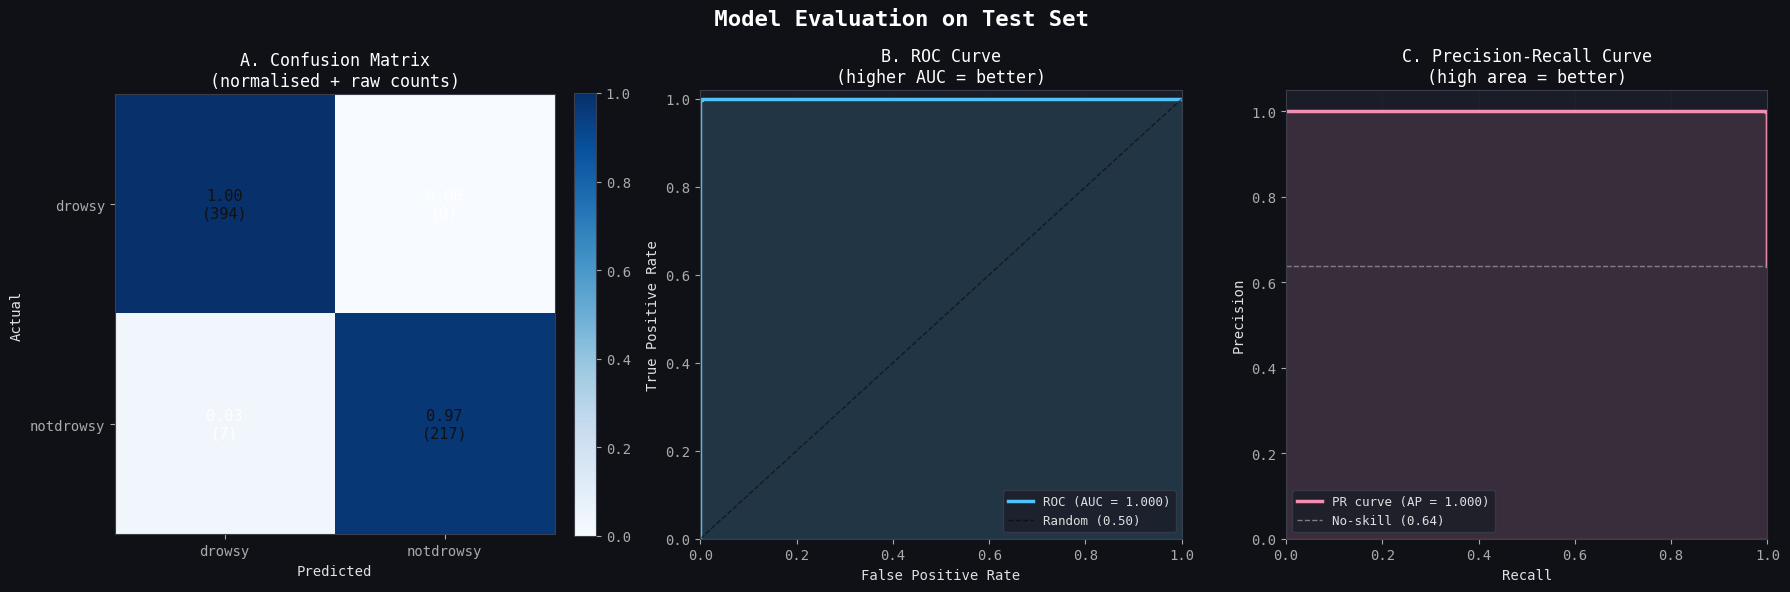

Evaluation charts saved to /content/evaluation_metrics.png


In [30]:
# EVALUATION PLOTS  (3 in one figure)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0f1117')
fig.suptitle(' Model Evaluation on Test Set',
             fontsize=16, fontweight='bold', color='white')

# Plot A: Confusion Matrix
# WHY: Raw counts of true positives, false positives, true negatives,
# false negatives. For drowsiness detection:
# - False Negative (missed drowsy) = DANGEROUS → minimise with high recall
# - False Positive (false alarm)   = Annoying but safe
ax = axes[0]
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
labels = [class_map[i] for i in sorted(class_map)]
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
thresh = cm_norm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i,
                f'{cm_norm[i,j]:.2f}\n({cm[i,j]})',
                ha='center', va='center', fontsize=11,
                color='white' if cm_norm[i,j] < thresh else '#111')
ax.set(xticks=range(len(labels)), yticks=range(len(labels)),
       xticklabels=labels, yticklabels=labels,
       xlabel='Predicted', ylabel='Actual',
       title='A. Confusion Matrix\n(normalised + raw counts)')
ax.tick_params(colors='#aaa')


# Plot B: ROC Curve
# WHY: Plots True Positive Rate vs False Positive Rate at every threshold.
# AUC = area under this curve. AUC=1 means perfect ranking.
# The dotted diagonal is a random classifier (AUC=0.5).
# You want the curve hugging the top-left corner.
ax = axes[1]
drowsy_idx  = list(test_gen.class_indices.values()).index(
    test_gen.class_indices.get('drowsy', 0))
fpr, tpr, _  = roc_curve(y_true, y_pred_proba[:, drowsy_idx],
                           pos_label=drowsy_idx)
roc_auc_val  = auc(fpr, tpr)
ax.plot(fpr, tpr, color='#4fc3f7', lw=2.5,
        label=f'ROC (AUC = {roc_auc_val:.3f})')
ax.fill_between(fpr, tpr, alpha=0.15, color='#4fc3f7')
ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5, label='Random (0.50)')
ax.set(xlim=[0,1], ylim=[0,1.02],
       xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='B. ROC Curve\n(higher AUC = better)')
ax.legend(fontsize=9)
ax.grid(**GRID_KW)


# Plot C: Precision-Recall Curve
# WHY: ROC is optimistic when classes are imbalanced.
# The Precision-Recall curve (PR curve) is more informative here.
# A high area under the PR curve means the model is accurate AND recalls
# drowsy cases without too many false alarms.
# The dashed line represents a no-skill classifier (baseline = class prevalence).
ax = axes[2]
precision_vals, recall_vals, _ = precision_recall_curve(
    y_true, y_pred_proba[:, drowsy_idx], pos_label=drowsy_idx)
ap = average_precision_score(
    y_true, y_pred_proba[:, drowsy_idx], pos_label=drowsy_idx)
ax.plot(recall_vals, precision_vals, color='#f48fb1', lw=2.5,
        label=f'PR curve (AP = {ap:.3f})')
ax.fill_between(recall_vals, precision_vals, alpha=0.15, color='#f48fb1')
drowsy_prevalence = np.mean(y_true == drowsy_idx)
ax.axhline(drowsy_prevalence, color='gray', linestyle='--', lw=1,
           label=f'No-skill ({drowsy_prevalence:.2f})')
ax.set(xlim=[0,1], ylim=[0,1.05],
       xlabel='Recall', ylabel='Precision',
       title='C. Precision-Recall Curve\n(high area = better)')
ax.legend(fontsize=9)
ax.grid(**GRID_KW)

plt.tight_layout()
plt.savefig('/content/evaluation_metrics.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('Evaluation charts saved to /content/evaluation_metrics.png')

## 11. Save Final Model & Copy to Drive

In [31]:
# Save the best (already done by ModelCheckpoint), but also save final
FINAL_PATH = '/content/models/final_blink_fatigue.keras'
model.save(FINAL_PATH)
print(f'Final model saved to {FINAL_PATH}')

# Copy back to Drive
try:
    import shutil
    DRIVE_DEST = '/content/drive/MyDrive/FYP/models/'
    os.makedirs(DRIVE_DEST, exist_ok=True)
    shutil.copy(MODEL_SAVE_PATH, DRIVE_DEST)
    shutil.copy(FINAL_PATH,      DRIVE_DEST)
    print(f'Models copied to Google Drive: {DRIVE_DEST}')
except Exception as e:
    print(f'Drive copy skipped: {e}')

Final model saved to /content/models/final_blink_fatigue.keras
Models copied to Google Drive: /content/drive/MyDrive/FYP/models/


## 12. Production Inference Class

Fixed: no `__file__` reference (crashes in Colab).

In [35]:
class DrowsinessDetector:
    """
    Production-ready inference wrapper.
    Accepts file path, bytes, or numpy array.
    """

    CLASS_NAMES = ['drowsy', 'notdrowsy']
    FATIGUE_LEVELS = [
        (0.80, 'Critical — High Fatigue'),
        (0.60, 'High Fatigue'),
        (0.40, 'Moderate Fatigue'),
        (0.20, 'Low Fatigue'),
        (0.00, 'Alert'),
    ]

    def __init__(self, model_path: str = MODEL_SAVE_PATH,
                 img_size: tuple = (IMG_HEIGHT, IMG_WIDTH),
                 threshold: float = DROWSY_THRESHOLD):
        self.img_size  = img_size
        self.threshold = threshold
        self.model     = keras.models.load_model(model_path)
        print(f'Model loaded from {model_path}')

    def _load_image(self, source):
        if isinstance(source, str):
            img = cv2.imread(source)
        elif isinstance(source, bytes):
            arr = np.frombuffer(source, np.uint8)
            img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        elif isinstance(source, np.ndarray):
            img = source
        else:
            raise TypeError(f'Expected str|bytes|ndarray, got {type(source)}')
        if img is None:
            raise ValueError('Failed to decode image')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.img_size[::-1])   # cv2 expects (w, h)
        return img.astype(np.float32)

    def predict(self, source):
        img     = self._load_image(source)
        batch   = np.expand_dims(img, 0)             # (1, H, W, 3)
        probs   = self.model.predict(batch, verbose=0)[0]
        # class_indices alphabetical: drowsy=0, notdrowsy=1
        drowsy_p    = float(probs[0])
        notdrowsy_p = float(probs[1])
        is_drowsy   = drowsy_p >= self.threshold
        return {
            'prediction'   : 'drowsy' if is_drowsy else 'notdrowsy',
            'confidence'   : drowsy_p if is_drowsy else notdrowsy_p,
            'probabilities': {'drowsy': drowsy_p, 'notdrowsy': notdrowsy_p},
            'fatigue_level': self._fatigue_level(drowsy_p),
            'alert'        : drowsy_p > 0.70,
            'timestamp'    : str(np.datetime64('now')),
        }

    def _fatigue_level(self, p):
        for threshold, label in self.FATIGUE_LEVELS:
            if p >= threshold:
                return label
        return 'Alert ✓'

    def predict_batch(self, sources):
        return [self.predict(s) for s in sources]

    def evaluate(self, test_path, batch_size=32):
        gen = ImageDataGenerator().flow_from_directory(
            test_path, target_size=self.img_size,
            batch_size=batch_size, class_mode='categorical', shuffle=False,
        )
        loss, acc = self.model.evaluate(gen, verbose=1)[:2]
        return {'test_accuracy': acc, 'test_loss': loss}


# Quick smoke test
detector = DrowsinessDetector(MODEL_SAVE_PATH)

# Grab first image from test set for a smoke test
first_class  = sorted(os.listdir(TEST_DATA_PATH))[0]
first_img    = os.listdir(os.path.join(TEST_DATA_PATH, first_class))[0]
sample_path  = os.path.join(TEST_DATA_PATH, first_class, first_img)

result = detector.predict(sample_path)
print('\nSample prediction:')
for k, v in result.items():
    print(f'  {k:15s}: {v}')

Model loaded from /content/models/best_blink_fatigue.keras



Sample prediction:
  prediction     : drowsy
  confidence     : 0.9992461800575256
  probabilities  : {'drowsy': 0.9992461800575256, 'notdrowsy': 0.0007538473000749946}
  fatigue_level  : Critical — High Fatigue
  alert          : True
  timestamp      : 2026-05-02T13:20:16
